<a href="https://colab.research.google.com/github/islombek-cs/Computer-Vision-Labs/blob/main/LAB10_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Islombek Abdurakhmanov  
**ID:** 221236  
**Shared Colab Link:** https://colab.research.google.com/drive/15jHw3LxAbYBjV8N15sP_vA1fI2V-ku0F?usp=sharing

# CV_LAB10 - Generative Adverserial Network

TASK - FIX ALL BUGS (LOGICAL) AND GENERATE NUMBERS.


*   Set runtime to GPU (T4)
*   Increase num_epochs (e.g., 10 or 15)
*   Implemenent Convolution Based Solution
https://colab.research.google.com/drive/1GpRf_pa9CERL9X3yDnYkdNlUyDlrHQPn?usp=sharing

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# SETTINGS
num_epochs = 15                    # Lab requirement: increase epochs
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# GENERATOR NETWORK
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 784),
            nn.Tanh()   # Output range (-1,1)
        )

    def forward(self, input):
        out = self.main(input)
        return out.view(-1, 1, 28, 28)   # reshape to image


# DISCRIMINATOR NETWORK
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, input):
        x = input.view(input.size(0), -1)   # flatten correctly
        return self.main(x)


# CREATE MODELS
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# LOAD MNIST DATASET
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalize to (-1,1)
])

full_dataset = dset.MNIST(root='./data', download=True, transform=transform)

# Optional test split (lab template)
test_size = 100
train_size = len(full_dataset) - test_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

real_label = 1.
fake_label = 0.

# TRAINING LOOP (CLEAN + FIXED)
for epoch in range(num_epochs):
    for i, (data, _) in enumerate(train_loader):

        # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        netD.zero_grad()

        # Train with real images
        real_data = data.to(device)
        b_size = real_data.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = netD(real_data).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Train with fake images
        noise = torch.randn(b_size, 100, device=device)
        fake_data = netG(noise)
        label.fill_(fake_label)

        output = netD(fake_data.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        # Update discriminator
        optimizerD.step()

        # (2) Update Generator: maximize log(D(G(z)))
        netG.zero_grad()
        label.fill_(real_label)  # fake images labeled as real

        output = netD(fake_data).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()

        optimizerG.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss_D: {(errD_real+errD_fake).item():.4f} "
          f"Loss_G: {errG.item():.4f} "
          f"D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}")


Using device: cuda
Epoch [1/15] Loss_D: 1.2233 Loss_G: 4.1126 D(x): 0.9772 D(G(z)): 0.6749/0.0164
Epoch [2/15] Loss_D: 1.0142 Loss_G: 17.0848 D(x): 0.9953 D(G(z)): 0.6025/0.0000
Epoch [3/15] Loss_D: 0.2850 Loss_G: 4.4286 D(x): 0.9630 D(G(z)): 0.1903/0.0131
Epoch [4/15] Loss_D: 0.2865 Loss_G: 3.3811 D(x): 0.8818 D(G(z)): 0.0311/0.0471
Epoch [5/15] Loss_D: 0.2058 Loss_G: 2.9179 D(x): 0.9271 D(G(z)): 0.0321/0.0747
Epoch [6/15] Loss_D: 0.4283 Loss_G: 2.6250 D(x): 0.9058 D(G(z)): 0.2340/0.0760
Epoch [7/15] Loss_D: 1.0983 Loss_G: 1.7720 D(x): 0.5061 D(G(z)): 0.0695/0.1923
Epoch [8/15] Loss_D: 1.0093 Loss_G: 1.9847 D(x): 0.7423 D(G(z)): 0.3805/0.1613
Epoch [9/15] Loss_D: 1.0663 Loss_G: 1.0236 D(x): 0.5131 D(G(z)): 0.0839/0.4089
Epoch [10/15] Loss_D: 0.8760 Loss_G: 2.6308 D(x): 0.7955 D(G(z)): 0.3807/0.0957
Epoch [11/15] Loss_D: 0.6226 Loss_G: 1.5664 D(x): 0.7122 D(G(z)): 0.1500/0.2491
Epoch [12/15] Loss_D: 0.9948 Loss_G: 1.8625 D(x): 0.7364 D(G(z)): 0.3413/0.1810
Epoch [13/15] Loss_D: 0.8361 

Now that the GAN is trained, we can use the generator to produce new images.

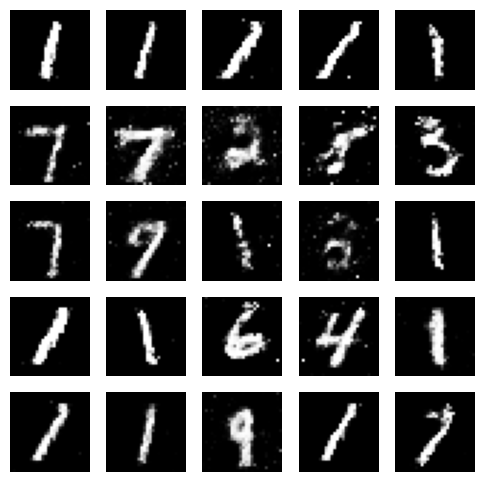

In [3]:
netG.eval()
num_images = 25
noise = torch.randn(num_images, 100, device=device)

with torch.no_grad():
    generated_images = netG(noise).cpu()

generated_images = generated_images * 0.5 + 0.5  # unnormalize

# DISPLAY RESULTS
fig = plt.figure(figsize=(6, 6))
for i in range(num_images):
    ax = fig.add_subplot(5, 5, i + 1)
    ax.imshow(generated_images[i][0], cmap="gray")
    ax.axis('off')

plt.show()